# Analisis de Resultados: NN vs PGNN0 vs PGNN

Notebook para extraer resultados existentes, consolidar metricas y graficar error vs inconsistencia fisica.

In [15]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Si conoces la ruta exacta del repo en este kernel, dejala aqui.
# Si no existe en este entorno, el codigo intentara auto-detectarla.
PROJECT_ROOT_OVERRIDE = Path('/home/isabel/PGNN')


def has_expected_results_structure(p: Path) -> bool:
    return (
        (p / 'results' / 'NN').exists()
        and (p / 'results' / 'PGNN0').exists()
        and (p / 'results' / 'PGNN').exists()
        and (p / 'datasets').exists()
    )


def count_result_files(p: Path) -> int:
    if not has_expected_results_structure(p):
        return 0
    total = 0
    for model in ['NN', 'PGNN0', 'PGNN']:
        total += len(list((p / 'results' / model).rglob('*_results.mat')))
    return total


def find_repo_by_signature() -> Path | None:
    # Busca en ubicaciones comunes sin recorrer todo el filesystem.
    search_bases = [Path.cwd(), Path('/home'), Path('/workspaces'), Path('/workspace'), Path('/content'), Path('/mnt')]
    best_path = None
    best_count = 0

    for base in search_bases:
        if not base.exists():
            continue

        # 1) Caso directo: la base ya es el repo
        c = count_result_files(base)
        if c > best_count:
            best_count = c
            best_path = base

        # 2) Busca carpetas llamadas PGNN (profundidad acotada por nombre)
        try:
            for candidate in base.rglob('PGNN'):
                if not candidate.is_dir():
                    continue
                c = count_result_files(candidate)
                if c > best_count:
                    best_count = c
                    best_path = candidate
        except Exception:
            # Algunas rutas pueden no permitir recorrido; se ignoran.
            pass

    return best_path


def find_project_root(start: Path) -> Path:
    # 1) Override manual
    if PROJECT_ROOT_OVERRIDE.exists() and has_expected_results_structure(PROJECT_ROOT_OVERRIDE):
        return PROJECT_ROOT_OVERRIDE

    # 2) Auto-deteccion hacia arriba desde cwd
    for p in [start] + list(start.parents):
        if has_expected_results_structure(p):
            return p

    # 3) Busqueda por firma de resultados
    found = find_repo_by_signature()
    if found is not None:
        return found

    # 4) Fallback final
    return start


# Rutas base de resultados
ROOT = find_project_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results'
MODEL_DIRS = {
    'NN': RESULTS_ROOT / 'NN',
    'PGNN0': RESULTS_ROOT / 'PGNN0',
    'PGNN': RESULTS_ROOT / 'PGNN'
}

n_files_detected = sum(len(list(d.rglob('*_results.mat'))) for d in MODEL_DIRS.values() if d.exists())

print('Directorio actual del kernel:', Path.cwd())
print('Root detectado del proyecto:', ROOT)
print('Carpeta de resultados:', RESULTS_ROOT)
print('Subcarpetas detectadas:', {k: v.exists() for k, v in MODEL_DIRS.items()})
print('Cantidad de archivos *_results.mat detectados:', n_files_detected)

if n_files_detected == 0:
    print('Aviso: este kernel no esta viendo tus resultados. Verifica que el runtime tenga acceso al workspace.')

Directorio actual del kernel: /home/isabel/PGNN
Root detectado del proyecto: /home/isabel/PGNN
Carpeta de resultados: /home/isabel/PGNN/results
Subcarpetas detectadas: {'NN': True, 'PGNN0': True, 'PGNN': True}
Cantidad de archivos *_results.mat detectados: 174


## 1) Cargar resultados existentes de NN, PGNN0 y PGNN

Esta celda recorre los archivos `.mat` y extrae metricas por corrida.

In [16]:
def scalar_from_mat_value(v):
    if v is None:
        return np.nan
    arr = np.asarray(v)
    if arr.size == 0:
        return np.nan
    return float(arr.reshape(-1)[0])


def extract_metrics(mat_dict):
    # Error: prioriza test_rmse
    error = scalar_from_mat_value(mat_dict.get('test_rmse'))
    if np.isnan(error):
        error = scalar_from_mat_value(mat_dict.get('rmse'))

    # Inconsistencia fisica: usa el campo mas especifico disponible
    phy_incon = scalar_from_mat_value(mat_dict.get('percentage_phy_incon'))
    if np.isnan(phy_incon):
        phy_incon = scalar_from_mat_value(mat_dict.get('physical_inconsistency'))

    # Fallback por compatibilidad con resultados antiguos
    if np.isnan(phy_incon):
        phy_incon = scalar_from_mat_value(mat_dict.get('phy_consistency'))

    return error, phy_incon


rows = []
for model_name, model_dir in MODEL_DIRS.items():
    if not model_dir.exists():
        continue

    for lake_name in ['mendota', 'mille_lacs']:
        lake_dir = model_dir / lake_name
        if not lake_dir.exists():
            continue

        for mat_path in lake_dir.glob('*_results.mat'):
        try:
            data = loadmat(mat_path)
            error, physical_inconsistency = extract_metrics(data)

            lake_name = mat_path.parent.name
            rows.append({
                'model': model_name,
                'lake': lake_name,
                'file': str(mat_path.relative_to(ROOT)),
                'error': error,
                'physical_inconsistency': physical_inconsistency
            })
        except Exception as e:
            rows.append({
                'model': model_name,
                'lake': mat_path.parent.name,
                'file': str(mat_path.relative_to(ROOT)),
                'error': np.nan,
                'physical_inconsistency': np.nan,
                'load_error': str(e)
            })

results_df = pd.DataFrame(rows)
print('Total archivos cargados:', len(results_df))
results_df.head()

IndentationError: expected an indented block after 'for' statement on line 38 (3379500382.py, line 39)

## 2) Calcular metricas y consolidar tabla comparativa

Se agregan estadisticos por modelo y por lago para inspeccion rapida.

In [ ]:
required_cols = ['model', 'lake', 'file', 'error', 'physical_inconsistency']

if results_df.empty:
    print('No se cargaron resultados. Revisa rutas en la celda 1.')
    clean_df = pd.DataFrame(columns=required_cols)
else:
    clean_df = results_df.copy()
    for col in required_cols:
        if col not in clean_df.columns:
            clean_df[col] = np.nan

clean_df['error'] = pd.to_numeric(clean_df['error'], errors='coerce')
clean_df['physical_inconsistency'] = pd.to_numeric(clean_df['physical_inconsistency'], errors='coerce')

valid_df = clean_df.dropna(subset=['error', 'physical_inconsistency']).copy()

if clean_df.empty:
    summary_table = pd.DataFrame(columns=[
        'model', 'lake', 'n_runs', 'n_with_error', 'n_with_phy', 'n_runs_used_plot',
        'error_mean', 'error_std', 'phy_incon_mean', 'phy_incon_std'
    ])
else:
    # Conteos de cobertura por modelo/lago
    coverage_table = (
        clean_df
        .groupby(['model', 'lake'], as_index=False)
        .agg(
            n_runs=('file', 'count'),
            n_with_error=('error', lambda s: s.notna().sum()),
            n_with_phy=('physical_inconsistency', lambda s: s.notna().sum())
        )
    )

    # Estadisticos solo con corridas que tienen ambas metricas (las que se pueden graficar)
    if valid_df.empty:
        stats_table = pd.DataFrame(columns=['model', 'lake', 'n_runs_used_plot', 'error_mean', 'error_std', 'phy_incon_mean', 'phy_incon_std'])
    else:
        stats_table = (
            valid_df
            .groupby(['model', 'lake'], as_index=False)
            .agg(
                n_runs_used_plot=('file', 'count'),
                error_mean=('error', 'mean'),
                error_std=('error', 'std'),
                phy_incon_mean=('physical_inconsistency', 'mean'),
                phy_incon_std=('physical_inconsistency', 'std')
            )
        )

    summary_table = (
        coverage_table
        .merge(stats_table, on=['model', 'lake'], how='left')
        .sort_values(['model', 'lake'])
        .reset_index(drop=True)
    )

print('Corridas cargadas (totales):', len(clean_df))
print('Corridas validas para grafica (error + physical_inconsistency):', len(valid_df))
display(summary_table)

if not valid_df.empty:
    display(
        valid_df[['model', 'lake', 'error', 'physical_inconsistency', 'file']]
        .sort_values(['model', 'lake', 'error'])
        .reset_index(drop=True)
    )

Corridas cargadas (totales): 175
Corridas validas para grafica (error + physical_inconsistency): 125


,model,lake,n_runs,n_with_error,n_with_phy,n_runs_used_plot,error_mean,error_std,phy_incon_mean,phy_incon_std
0,NN,_archive_modern_or_outliers,3,3,3,3,12.893093,0.263482,0.309374,0.184684
1,NN,mendota,52,52,51,51,2.698381,2.861593,0.291282,0.131171
2,NN,mille_lacs,51,51,3,3,8.439786,5.234394,0.517327,0.054840
3,PGNN,mendota,18,18,18,18,1.666431,0.117282,0.071894,0.032492
4,PGNN0,mendota,51,51,50,50,1.653711,0.140706,0.320394,0.058053


,model,lake,error,physical_inconsistency,file
0,NN,_archive_modern_or_outliers,12.734444,0.127374,results/NN/mendota/_archive_modern_or_outliers...
1,NN,_archive_modern_or_outliers,12.747595,0.496630,results/NN/mendota/_archive_modern_or_outliers...
2,NN,_archive_modern_or_outliers,13.197242,0.304117,results/NN/mendota/_archive_modern_or_outliers...
3,NN,mendota,1.539151,0.295133,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...
4,NN,mendota,1.591428,0.253968,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...
...,...,...,...,...,...
120,PGNN0,mendota,1.896203,0.249457,results/PGNN0/mendota/pgnn_mendotaAdadelta_dro...
121,PGNN0,mendota,1.905898,0.329491,results/PGNN0/mendota/pgnn_mendotaAdadelta_dro...
122,PGNN0,mendota,1.910054,0.400894,results/PGNN0/mendota/pgnn_mendotaAdadelta_dro...
123,PGNN0,mendota,1.922157,0.369716,results/PGNN0/mendota/pgnn_mendotaAdadelta_dro...


## 3) Graficar un punto por modelo (media ± desviacion) por lago

Como en el paper:
- Eje X: Physical Inconsistency (media ± std)
- Eje Y: Test RMSE (media ± std)
- Un solo punto por modelo (NN, PGNN0, PGNN)
- Una figura independiente por lago

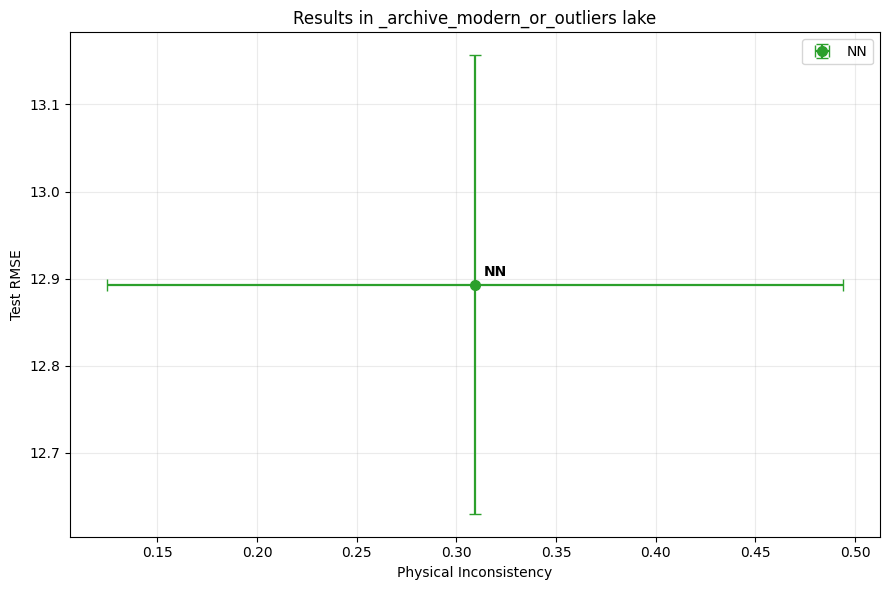

,model,error_mean,error_std,phy_mean,phy_std,n_runs
0,NN,12.893093,0.263482,0.309374,0.184684,3


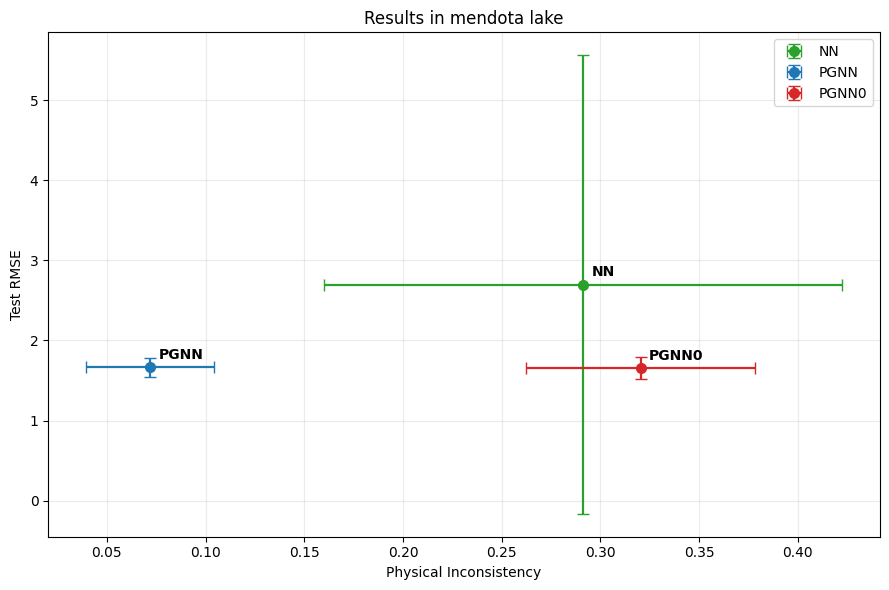

,model,error_mean,error_std,phy_mean,phy_std,n_runs
0,NN,2.698381,2.861593,0.291282,0.131171,51
1,PGNN,1.666431,0.117282,0.071894,0.032492,18
2,PGNN0,1.653711,0.140706,0.320394,0.058053,50


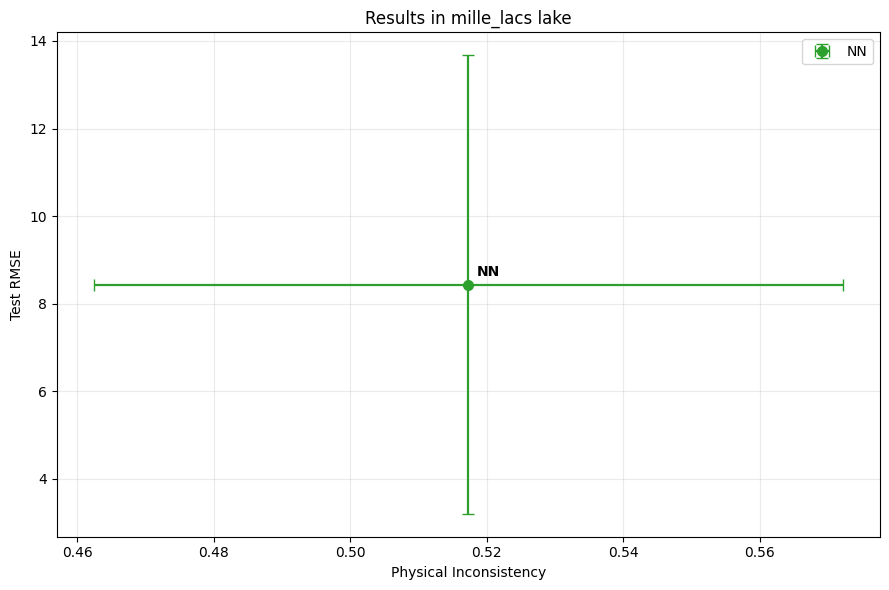

,model,error_mean,error_std,phy_mean,phy_std,n_runs
0,NN,8.439786,5.234394,0.517327,0.05484,3


In [17]:
plot_df = valid_df.copy()

if plot_df.empty:
    print('No hay datos validos para graficar.')
else:
    model_colors = {
        'NN': '#2ca02c',
        'PGNN0': '#d62728',
        'PGNN': '#1f77b4'
    }

    lakes_to_plot = sorted(plot_df['lake'].dropna().unique())

    for lake_name in lakes_to_plot:
        lake_df = plot_df[plot_df['lake'] == lake_name].copy()
        if lake_df.empty:
            print(f'No hay datos validos para {lake_name}.')
            continue

        model_stats = (
            lake_df
            .groupby('model', as_index=False)
            .agg(
                error_mean=('error', 'mean'),
                error_std=('error', 'std'),
                phy_mean=('physical_inconsistency', 'mean'),
                phy_std=('physical_inconsistency', 'std'),
                n_runs=('model', 'count')
            )
        )

        # Si un modelo tiene una sola corrida, std queda NaN; se reemplaza por 0 para graficar.
        for c in ['error_std', 'phy_std']:
            model_stats[c] = model_stats[c].fillna(0.0)

        plt.figure(figsize=(9, 6))

        for _, row in model_stats.iterrows():
            model = row['model']
            x = row['phy_mean']
            y = row['error_mean']
            xerr = row['phy_std']
            yerr = row['error_std']

            plt.errorbar(
                x,
                y,
                xerr=xerr,
                yerr=yerr,
                fmt='o',
                markersize=7,
                capsize=4,
                elinewidth=1.6,
                color=model_colors.get(model, '#7f7f7f'),
                label=model
            )

            plt.annotate(
                model,
                (x, y),
                textcoords='offset points',
                xytext=(6, 6),
                fontsize=10,
                weight='bold'
            )

        plt.xlabel('Physical Inconsistency')
        plt.ylabel('Test RMSE')
        plt.title(f'Results in {lake_name} lake')
        plt.grid(alpha=0.25)
        plt.legend(frameon=True, fontsize=10)
        plt.tight_layout()
        plt.show()

        display(model_stats.sort_values('model').reset_index(drop=True))